<a href="https://colab.research.google.com/github/mithun30052001/capstone-project/blob/main/Part2-Supervised-Machine-Learning/Supervised_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Load data and define targets
print("Loading cleaned dataset...")
df = pd.read_csv('cleaned_data.csv', low_memory=False)
print('Shape of cleaned data', df.shape)
print('Inspecting cleaned data',df.describe())

# Define Regression Label: 'days_to_forward'
y_reg = df['days_to_forward']

# Define Classification Label: Binarize at the 75th percentile to force an imbalance
# 1 = Extreme Delay (Top 25% longest delays), 0 = Normal Speed
threshold_val = y_reg.quantile(0.75)
y_clf = (y_reg > threshold_val).astype(int)

# Define Feature Matrix X
# Drop targets, raw text, datetime columns, and useless IDs to prevent data leakage
cols_to_drop = [
    'days_to_forward', 'date_received', 'date_sent',
    'Date received', 'Date sent to company',
    'Consumer complaint narrative', 'Company public response',
    'ZIP code', 'Complaint ID'
]
X_raw = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"Regression target (y_reg) shape: {y_reg.shape}")
print(f"Classification target (y_clf) distribution:\n{y_clf.value_counts(normalize=True) * 100}")

Loading cleaned dataset...
Shape of cleaned data (99944, 22)
Inspecting cleaned data        Complaint ID  days_to_forward  narrative_length  \
count  9.994400e+04     99944.000000       2379.000000   
mean   2.300701e+07         0.224176       1350.433375   
std    1.629918e+06         4.060330       1357.736405   
min    5.553878e+06       -53.000000         51.000000   
25%    2.217046e+07         0.000000        474.000000   
50%    2.390050e+07         0.000000       1040.000000   
75%    2.408819e+07         0.000000       1763.000000   
max    2.412839e+07       297.000000      17154.000000   

       company_response_length  ZIP code numeric  
count             99944.000000      93553.000000  
mean                 94.938365      49209.970968  
std                   1.310138      27376.894297  
min                  53.000000        602.000000  
25%                  95.000000      30075.000000  
50%                  95.000000      38016.000000  
75%                  95.000000     

In [7]:
# Task 2: Encode Categorical Columns

# A. Label Encoding for Natural Order
# We map 'Submitted via' based on manual processing friction (Web is fastest, Mail is slowest)
speed_mapping = {
    'Web': 1,
    'Phone': 2,
    'Referral': 2,
    'Fax': 3,
    'Postal mail': 3
}
if 'Submitted via' in X_raw.columns:
    X_raw['Submitted via_encoded'] = X_raw['Submitted via'].map(speed_mapping).fillna(2)
    X_raw = X_raw.drop(columns=['Submitted via'])

# B. One-Hot Encoding for Non-Ordinal columns
# Select remaining object/category columns
cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

# Drop the first dummy to avoid multicollinearity
X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

# Fill any residual NaNs with 0 for safety before scaling
X_encoded = X_encoded.fillna(0)

print(f"Shape of Feature Matrix after Encoding: {X_encoded.shape}")

Shape of Feature Matrix after Encoding: (99944, 1288)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Task 3:Leak-free Train-Test Split (Splitting X alongside BOTH y labels)
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_encoded, y_reg, y_clf, test_size=0.2, random_state=42
)

# Fitting the scaler ONLY on the training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transforming the test set using the learned training statistics
X_test_scaled = scaler.transform(X_test)

print("Train and Test sets split and scaled successfully.")

Train and Test sets split and scaled successfully.


In [12]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Task 4: Regression model — Linear Regression:
# 1. OLS Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_reg_train)
y_pred_lr = lr_model.predict(X_test_scaled)

lr_mse = mean_squared_error(y_reg_test, y_pred_lr)
lr_r2 = r2_score(y_reg_test, y_pred_lr)

# Get top 3 absolute coefficients
coeff_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False)

print("--- OLS Linear Regression ---")
print(f"MSE: {lr_mse:.4f}")
print(f"R²:  {lr_r2:.4f}")
print("\nTop 3 Features by Absolute Coefficient:")
display(coeff_df.head(3)[['Feature', 'Coefficient']])

# 2. Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_reg_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_reg_test, y_pred_ridge)
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)

print("\n--- Regression Comparison Table ---")
comparison = pd.DataFrame({
    'Model': ['OLS Linear Regression', 'Ridge Regression (alpha=1.0)'],
    'MSE': [lr_mse, ridge_mse],
    'R²': [lr_r2, ridge_r2]
})
display(comparison)

--- OLS Linear Regression ---
MSE: 12.2526
R²:  -0.0076

Top 3 Features by Absolute Coefficient:


,Feature,Coefficient
103,Issue_Managing the loan or lease,1.798854
139,Issue_Trouble during payment process,-1.492733
164,Sub-issue_Billing problem,-1.090296



--- Regression Comparison Table ---


,Model,MSE,R²
0,OLS Linear Regression,12.252605,-0.007578
1,Ridge Regression (alpha=1.0),12.248992,-0.007281


--- Class Imbalance Check ---
days_to_forward
0    99.203302
1     0.796698
Name: proportion, dtype: float64

Because the minority class is < 35%, we use class_weight='balanced' to handle the imbalance.

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     19833
           1       0.04      0.49      0.07       156

    accuracy                           0.90     19989
   macro avg       0.52      0.70      0.51     19989
weighted avg       0.99      0.90      0.94     19989

--- Confusion Matrix ---


,Pred Fast (0),Pred Delay (1)
Actual Fast (0),17867,1966
Actual Delay (1),79,77


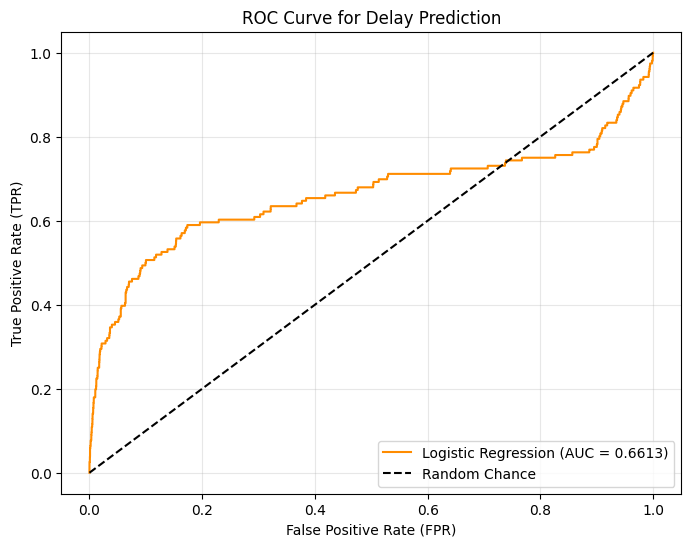

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

print("--- Class Imbalance Check ---")
print(y_clf_train.value_counts(normalize=True) * 100)
print("\nBecause the minority class is < 35%, we use class_weight='balanced' to handle the imbalance.")

# Task 5: Logistic Regression with class balancing
clf_model = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0)
clf_model.fit(X_train_scaled, y_clf_train)

# Predictions
y_pred_clf = clf_model.predict(X_test_scaled)
y_proba_clf = clf_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_clf_test, y_pred_clf))

print("--- Confusion Matrix ---")
display(pd.DataFrame(confusion_matrix(y_clf_test, y_pred_clf),
                     columns=['Pred Fast (0)', 'Pred Delay (1)'],
                     index=['Actual Fast (0)', 'Actual Delay (1)']))

# ROC Curve & AUC
auc_score = roc_auc_score(y_clf_test, y_proba_clf)
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve for Delay Prediction')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]
results = []

for thresh in thresholds_to_test:
    # Convert probabilities to binary predictions using custom threshold
    custom_preds = (y_proba_clf >= thresh).astype(int)

    prec = precision_score(y_clf_test, custom_preds, zero_division=0)
    rec = recall_score(y_clf_test, custom_preds, zero_division=0)
    f1 = f1_score(y_clf_test, custom_preds, zero_division=0)

    results.append({'Threshold': thresh, 'Precision': prec, 'Recall': rec, 'F1': f1})

thresh_df = pd.DataFrame(results)
print("--- Decision Threshold Sensitivity Analysis ---")
display(thresh_df)

--- Decision Threshold Sensitivity Analysis ---


,Threshold,Precision,Recall,F1
0,0.3,0.021103,0.596154,0.040763
1,0.4,0.026476,0.557692,0.050552
2,0.5,0.037690,0.493590,0.070032
3,0.6,0.049593,0.429487,0.088918
4,0.7,0.063146,0.352564,0.107108


In [15]:
# Task 6: Regularization Experiment: Stronger L2 Penalty (C=0.01)
clf_model_strong = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.01)
clf_model_strong.fit(X_train_scaled, y_clf_train)

y_pred_strong = clf_model_strong.predict(X_test_scaled)
y_proba_strong = clf_model_strong.predict_proba(X_test_scaled)[:, 1]

auc_strong = roc_auc_score(y_clf_test, y_proba_strong)
prec_strong = precision_score(y_clf_test, y_pred_strong)
rec_strong = recall_score(y_clf_test, y_pred_strong)

print("--- Regularization Comparison (C=1.0 vs C=0.01) ---")
reg_comp = pd.DataFrame({
    'Model': ['Baseline (C=1.0)', 'Strong Reg (C=0.01)'],
    'Precision': [precision_score(y_clf_test, y_pred_clf), prec_strong],
    'Recall': [recall_score(y_clf_test, y_pred_clf), rec_strong],
    'AUC': [auc_score, auc_strong]
})
display(reg_comp)

# Task 7: Bootstrap Confidence Interval for AUC difference
print("\n--- Running Bootstrap (n=500) for AUC Difference... ---")
np.random.seed(42)
n_iterations = 500
auc_diffs = []

y_test_arr = np.array(y_clf_test)
proba_1_arr = np.array(y_proba_clf)    # C=1.0
proba_2_arr = np.array(y_proba_strong) # C=0.01
n_size = len(y_test_arr)

for i in range(n_iterations):
    # Sample with replacement
    indices = np.random.choice(n_size, size=n_size, replace=True)

    y_sample = y_test_arr[indices]

    # Must have both classes in the sample to calculate AUC
    if len(np.unique(y_sample)) < 2:
        continue

    auc1 = roc_auc_score(y_sample, proba_1_arr[indices])
    auc2 = roc_auc_score(y_sample, proba_2_arr[indices])

    auc_diffs.append(auc1 - auc2)

mean_diff = np.mean(auc_diffs)
ci_lower = np.percentile(auc_diffs, 2.5)
ci_upper = np.percentile(auc_diffs, 97.5)

print(f"Mean AUC Difference (C=1.0 minus C=0.01): {mean_diff:.5f}")
print(f"95% Confidence Interval: [{ci_lower:.5f}, {ci_upper:.5f}]")

if ci_lower > 0 or ci_upper < 0:
    print("Conclusion: The interval EXCLUDES zero. The performance difference is statistically reliable.")
else:
    print("Conclusion: The interval INCLUDES zero. We cannot confidently say one model is universally better.")

--- Regularization Comparison (C=1.0 vs C=0.01) ---


,Model,Precision,Recall,AUC
0,Baseline (C=1.0),0.037690,0.493590,0.661328
1,Strong Reg (C=0.01),0.039378,0.519231,0.708560



--- Running Bootstrap (n=500) for AUC Difference... ---
Mean AUC Difference (C=1.0 minus C=0.01): -0.04757
95% Confidence Interval: [-0.06996, -0.02756]
Conclusion: The interval EXCLUDES zero. The performance difference is statistically reliable.
